# Wpływ funkcji Focal Loss na odporność modelu ResNet50 przy trudnych warunkach oświetleniowych

Celem eksperymentu jest określenie, czy zastosowanie funkcji Focal Loss podczas treningu zwiększa skuteczność i odporność modelu ResNet50 na trudne warunki oświetleniowe.

W eksperymencie porównane zostaną dwie konfiguracje:

- `lighting_augmentation + CrossEntropyLoss`,
- `lighting_augmentation + Focal Loss`.

Obie konfiguracje wykorzystują:

- architekturę `ResNet50`,
- wstępnie wytrenowane wagi ImageNet,
- `WeightedRandomSampler`,
- augmentację oświetleniową stosowaną podczas treningu,
- identyczny podział danych,
- identyczne parametry optymalizacji.

Podstawowym kryterium porównania jest średnia wartość `Macro F1` dla kontrolowanych wariantów zaciemnienia `dark_1`, `dark_2` i `dark_3`.

Dodatkowo analizowana jest skuteczność dla obrazów oryginalnych oraz degradacja skuteczności pomiędzy obrazem oryginalnym a wariantem `dark_3`.

Zbiór `test_final` zostanie wykorzystany wyłącznie do końcowej oceny konfiguracji wybranej na podstawie zbioru walidacyjnego.

In [ ]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report,
)

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.sampling import (
    build_weighted_sampler,
)

from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
    RandomLightingAugmentation,
)

from src.models.resnet50 import (
    create_resnet50,
    freeze_resnet50_backbone,
    unfreeze_resnet50_last_block,
)

from src.training.trainer import (
    fit,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    /"data"
    / "data"
    / "processed"
    / "metadata"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

HISTORIES_DIR = (
    RESULTS_DIR
    / "histories"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "focal_loss"
)

FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)


for directory in [
    METRICS_DIR,
    HISTORIES_DIR,
    CHECKPOINT_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Konfiguracja eksperymentu
(FROZEN_EPOCHS = 5, FINE_TUNE_EPOCHS = 2)

In [3]:
IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = 0

FROZEN_EPOCHS = 5 #10

FINE_TUNE_EPOCHS = 2 #5

FROZEN_LR = 1e-3

FINE_TUNE_LR = 1e-5

RANDOM_SEED = 42

PRETRAINED = True


FOCAL_GAMMA = 2.0


CONFIGURATIONS = [
    {
        "name": "lighting_augmentation_ce",
        "loss": "cross_entropy",
    },

    {
        "name": "lighting_augmentation_focal",
        "loss": "focal",
    },
]


LIGHTING_VARIANTS = [
    "original",
    "dark_1",
    "dark_2",
    "dark_3",
]


print(
    "FOCAL_GAMMA:",
    FOCAL_GAMMA
)

print(
    "Konfiguracje:"
)

for configuration in CONFIGURATIONS:

    print(
        configuration
    )

FOCAL_GAMMA: 2.0
Konfiguracje:
{'name': 'lighting_augmentation_ce', 'loss': 'cross_entropy'}
{'name': 'lighting_augmentation_focal', 'loss': 'focal'}


## 2. Wczytanie manifestów i mapowanie klas

In [4]:
TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "TRAIN:",
    len(train_df)
)

print(
    "VALIDATION:",
    len(validation_df)
)

print(
    "TEST_FINAL:",
    len(test_df)
)

Liczba klas: 92
TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 3. Augmentacja oświetleniowa

Augmentacja oświetleniowa jest identyczna jak w poprzednim eksperymencie.

Podczas treningu obrazy mogą zostać losowo poddane zmianie jasności i kontrastu.

Walidacja i test pozostają deterministyczne i nie wykorzystują losowej augmentacji.

In [5]:
from torchvision import transforms


normalization = transforms.Normalize(
    mean=(
        0.485,
        0.456,
        0.406,
    ),
    std=(
        0.229,
        0.224,
        0.225,
    ),
)


def build_training_transform():

    return transforms.Compose(
        [
            RandomLightingAugmentation(
                brightness_range=(
                    0.5,
                    1.3,
                ),
                contrast_range=(
                    0.8,
                    1.2,
                ),
                probability=0.8,
            ),

            transforms.Resize(
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                )
            ),

            transforms.RandomRotation(
                10
            ),

            transforms.ToTensor(),

            normalization,
        ]
    )


def build_evaluation_transform():

    return transforms.Compose(
        [
            transforms.Resize(
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                )
            ),

            transforms.ToTensor(),

            normalization,
        ]
    )

## 4. Focal Loss

Focal Loss modyfikuje standardową funkcję Cross Entropy poprzez zmniejszenie wpływu przykładów, które są już klasyfikowane z wysoką pewnością, oraz zwiększenie względnego znaczenia przykładów trudnych.

W eksperymencie stosowana jest wartość parametru `gamma = 2.0`.

In [6]:
class FocalLoss(
    nn.Module
):

    def __init__(
        self,
        gamma=2.0,
        reduction="mean",
    ):

        super().__init__()

        if gamma < 0:

            raise ValueError(
                "Parametr gamma "
                "musi być >= 0."
            )


        if reduction not in [
            "mean",
            "sum",
            "none",
        ]:

            raise ValueError(
                "Nieprawidłowy reduction."
            )


        self.gamma = gamma

        self.reduction = reduction


    def forward(
        self,
        logits,
        targets,
    ):

        log_prob = F.log_softmax(
            logits,
            dim=1,
        )


        log_pt = log_prob.gather(
            1,
            targets.unsqueeze(1),
        ).squeeze(1)


        pt = log_pt.exp()


        focal_factor = (
            1.0 - pt
        ).pow(
            self.gamma
        )


        loss = (
            -focal_factor
            * log_pt
        )


        if self.reduction == "mean":

            return loss.mean()


        if self.reduction == "sum":

            return loss.sum()


        return loss

## 5. Kontrola poprawności funkcji straty

In [7]:
test_logits = torch.tensor(
    [
        [5.0, 0.5, 0.2],
        [0.2, 5.0, 0.5],
        [0.5, 0.2, 5.0],
    ]
)

test_targets = torch.tensor(
    [
        0,
        1,
        2,
    ]
)


ce = nn.CrossEntropyLoss()

focal = FocalLoss(
    gamma=FOCAL_GAMMA
)


print(
    "CrossEntropyLoss:",
    float(
        ce(
            test_logits,
            test_targets,
        )
    )
)


print(
    "FocalLoss:",
    float(
        focal(
            test_logits,
            test_targets,
        )
    )
)

CrossEntropyLoss: 0.019154110923409462
FocalLoss: 6.894167654536432e-06


## 6. DataLoadery

In [8]:
def build_loaders():

    train_dataset = (
        TrafficSignDataset(
            TRAIN_PATH,
            class_to_idx,
            transform=(
                build_training_transform()
            ),
        )
    )


    validation_dataset = (
        TrafficSignDataset(
            VALIDATION_PATH,
            class_to_idx,
            transform=(
                build_evaluation_transform()
            ),
        )
    )


    weighted_sampler = (
        build_weighted_sampler(
            TRAIN_PATH
        )
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=weighted_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    return (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    )

## 7. Funkcja tworzenia modelu

In [9]:
def create_model():

    model = create_resnet50(
        num_classes=len(
            class_codes
        ),
        pretrained=PRETRAINED,
    )


    model = (
        freeze_resnet50_backbone(
            model
        )
    )


    model = model.to(
        DEVICE
    )


    return model

## 8. Funkcja przygotowania funkcji straty

In [10]:
def build_loss(
    loss_name
):

    if loss_name == "cross_entropy":

        return nn.CrossEntropyLoss()


    if loss_name == "focal":

        return FocalLoss(
            gamma=FOCAL_GAMMA,
            reduction="mean",
        )


    raise ValueError(
        f"Nieznana funkcja straty: "
        f"{loss_name}"
    )

## 9. Funkcja treningu pojedynczej konfiguracji

Każda konfiguracja jest trenowana w dwóch etapach:

1. trening głowicy klasyfikacyjnej przy zamrożonym backbone,
2. fine-tuning końcowego bloku ResNet50 oraz głowicy klasyfikacyjnej.

Jedynym elementem różniącym konfiguracje jest funkcja straty.

In [11]:
def train_configuration(
    configuration,
):

    name = configuration[
        "name"
    ]

    loss_name = configuration[
        "loss"
    ]


    print(
        "\n"
        + "=" * 80
    )

    print(
        f"Konfiguracja: {name}"
    )

    print(
        f"Loss: {loss_name}"
    )

    print(
        "=" * 80
    )


    set_seed(
        RANDOM_SEED
    )


    (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    ) = build_loaders()


    model = create_model()


    criterion = build_loss(
        loss_name
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FROZEN_LR,
    )


    frozen_checkpoint = (
        CHECKPOINT_DIR
        / (
            f"resnet50_"
            f"{name}_"
            f"frozen_best.pt"
        )
    )


    frozen_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FROZEN_EPOCHS,
        checkpoint_path=frozen_checkpoint,
    )


    model = (
        unfreeze_resnet50_last_block(
            model
        )
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FINE_TUNE_LR,
    )


    finetuned_checkpoint = (
        CHECKPOINT_DIR
        / (
            f"resnet50_"
            f"{name}_"
            f"finetuned_best.pt"
        )
    )


    finetune_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FINE_TUNE_EPOCHS,
        checkpoint_path=finetuned_checkpoint,
    )


    model.eval()


    return {
        "configuration":
            configuration,

        "model":
            model,

        "train_dataset":
            train_dataset,

        "validation_dataset":
            validation_dataset,

        "train_loader":
            train_loader,

        "validation_loader":
            validation_loader,

        "frozen_history":
            frozen_history,

        "finetune_history":
            finetune_history,
    }

## 10. Trening konfiguracji Cross Entropy

In [12]:
ce_experiment = (
    train_configuration(
        CONFIGURATIONS[0]
    )
)


Konfiguracja: lighting_augmentation_ce
Loss: cross_entropy


Postęp treningu:   0%|          | 0/5 [00:00<?, ?it/s]

Epoka 1/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/5:   0%|          | 0/445 [00:03<?, ?it/s]

Epoka 3/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 5/5:   0%|          | 0/445 [00:00<?, ?it/s]

Postęp treningu:   0%|          | 0/2 [00:00<?, ?it/s]

Epoka 1/2:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/2:   0%|          | 0/445 [00:00<?, ?it/s]

## 11. Trening konfiguracji Focal Loss

In [13]:
focal_experiment = (
    train_configuration(
        CONFIGURATIONS[1]
    )
)


Konfiguracja: lighting_augmentation_focal
Loss: focal


Postęp treningu:   0%|          | 0/5 [00:00<?, ?it/s]

Epoka 1/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 5/5:   0%|          | 0/445 [00:00<?, ?it/s]

Postęp treningu:   0%|          | 0/2 [00:00<?, ?it/s]

Epoka 1/2:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/2:   0%|          | 0/445 [00:00<?, ?it/s]

## 12. Zestawienie modeli

In [14]:
experiments = {
    "lighting_augmentation_ce":
        ce_experiment,

    "lighting_augmentation_focal":
        focal_experiment,
}


print(
    "Dostępne modele:"
)

for name in experiments:
    print(
        name
    )

Dostępne modele:
lighting_augmentation_ce
lighting_augmentation_focal


## 13. Skuteczność na standardowym zbiorze walidacyjnym

In [15]:
standard_results = []


for name, experiment in (
    experiments.items()
):

    y_true, y_pred, inference_time = (
        predict(
            experiment[
                "model"
            ],
            experiment[
                "validation_loader"
            ],
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    standard_results.append(
        {
            "configuration":
                name,

            "accuracy":
                metrics[
                    "accuracy"
                ],

            "macro_precision":
                metrics[
                    "macro_precision"
                ],

            "macro_recall":
                metrics[
                    "macro_recall"
                ],

            "macro_f1":
                metrics[
                    "macro_f1"
                ],

            "inference_time_seconds":
                inference_time,
        }
    )


standard_validation_df = (
    pd.DataFrame(
        standard_results
    )
    .sort_values(
        "macro_f1",
        ascending=False,
    )
)


display(
    standard_validation_df
)

,configuration,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,lighting_augmentation_ce,0.898885,0.891431,0.903490,0.891685,193.211747
1,lighting_augmentation_focal,0.894506,0.886345,0.892681,0.884802,191.530863


## 14. Ocena odporności na kontrolowane zaciemnienie

Każdy model jest oceniany na tych samych trzech poziomach zaciemnienia.

Do ewaluacji nie jest stosowana losowa augmentacja treningowa.

In [16]:
def evaluate_lighting_variant(
    model,
    variant,
):

    dataset = (
        ControlledLightingDataset(
            VALIDATION_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=(
                build_evaluation_transform()
            ),
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    return {
        "samples":
            len(dataset),

        "accuracy":
            metrics[
                "accuracy"
            ],

        "macro_precision":
            metrics[
                "macro_precision"
            ],

        "macro_recall":
            metrics[
                "macro_recall"
            ],

        "macro_f1":
            metrics[
                "macro_f1"
            ],

        "inference_time_seconds":
            inference_time,
    }

In [17]:
lighting_results = []


for name, experiment in (
    experiments.items()
):

    model = experiment[
        "model"
    ]


    for variant in LIGHTING_VARIANTS:

        print(
            f"Konfiguracja: {name} | "
            f"Wariant: {variant}"
        )


        metrics = (
            evaluate_lighting_variant(
                model=model,
                variant=variant,
            )
        )


        lighting_results.append(
            {
                "configuration":
                    name,

                "variant":
                    variant,

                "factor":
                    LIGHTING_FACTORS[
                        variant
                    ],

                **metrics,
            }
        )


lighting_results_df = (
    pd.DataFrame(
        lighting_results
    )
)


display(
    lighting_results_df
)

Konfiguracja: lighting_augmentation_ce | Wariant: original
Konfiguracja: lighting_augmentation_ce | Wariant: dark_1
Konfiguracja: lighting_augmentation_ce | Wariant: dark_2
Konfiguracja: lighting_augmentation_ce | Wariant: dark_3
Konfiguracja: lighting_augmentation_focal | Wariant: original
Konfiguracja: lighting_augmentation_focal | Wariant: dark_1
Konfiguracja: lighting_augmentation_focal | Wariant: dark_2
Konfiguracja: lighting_augmentation_focal | Wariant: dark_3


,configuration,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,lighting_augmentation_ce,original,1.0,2512,0.898885,0.891431,0.903490,0.891685,190.774007
1,lighting_augmentation_ce,dark_1,0.7,2512,0.892914,0.887349,0.909151,0.894617,184.100544
2,lighting_augmentation_ce,dark_2,0.5,2512,0.878185,0.866726,0.891113,0.872034,181.288267
3,lighting_augmentation_ce,dark_3,0.3,2512,0.860271,0.836440,0.868826,0.841973,184.746853
4,lighting_augmentation_focal,original,1.0,2512,0.894506,0.886345,0.892681,0.884802,187.567067
5,lighting_augmentation_focal,dark_1,0.7,2512,0.892516,0.887168,0.900486,0.889635,186.685541
6,lighting_augmentation_focal,dark_2,0.5,2512,0.876194,0.867223,0.874115,0.862783,201.354055
7,lighting_augmentation_focal,dark_3,0.3,2512,0.862261,0.831176,0.851598,0.832663,193.408493


## 15. Podsumowanie odporności na zaciemnienie

In [18]:
dark_results = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
)


mean_dark = (
    dark_results
    .groupby(
        "configuration"
    )[
        "macro_f1"
    ]
    .mean()
    .rename(
        "mean_dark_macro_f1"
    )
)


dark3 = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ] == "dark_3"
    ]
    [
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "dark3_macro_f1"
        }
    )
)


standard = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ] == "original"
    ]
    [
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "standard_macro_f1"
        }
    )
)


robustness_summary = (
    mean_dark
    .to_frame()
    .join(
        dark3
    )
    .join(
        standard
    )
)


robustness_summary[
    "f1_drop_to_dark3"
] = (
    robustness_summary[
        "standard_macro_f1"
    ]
    -
    robustness_summary[
        "dark3_macro_f1"
    ]
)


robustness_summary = (
    robustness_summary
    .sort_values(
        "mean_dark_macro_f1",
        ascending=False,
    )
)


display(
    robustness_summary
)

,mean_dark_macro_f1,dark3_macro_f1,standard_macro_f1,f1_drop_to_dark3
configuration,,,,
lighting_augmentation_ce,0.869541,0.841973,0.891685,0.049711
lighting_augmentation_focal,0.861694,0.832663,0.884802,0.052139


## 16. Porównanie Cross Entropy i Focal Loss dla kolejnych poziomów zaciemnienia

configuration,lighting_augmentation_ce,lighting_augmentation_focal
variant,,
dark_1,0.894617,0.889635
dark_2,0.872034,0.862783
dark_3,0.841973,0.832663


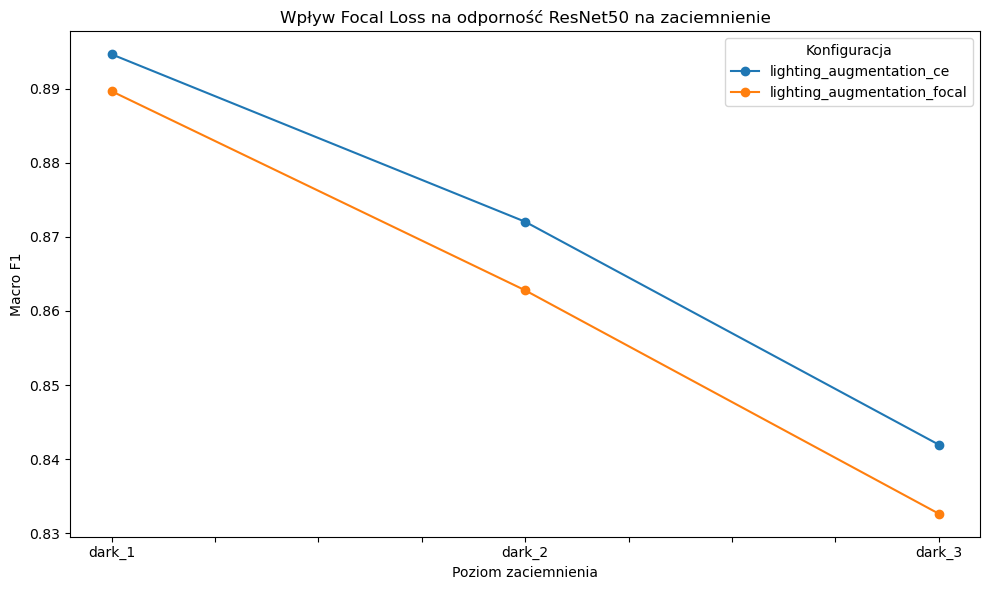

In [19]:
dark_plot = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
    .pivot(
        index="variant",
        columns="configuration",
        values="macro_f1",
    )
    .reindex(
        [
            "dark_1",
            "dark_2",
            "dark_3",
        ]
    )
)


display(
    dark_plot
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


dark_plot.plot(
    marker="o",
    ax=ax,
)


ax.set_title(
    "Wpływ Focal Loss na odporność "
    "ResNet50 na zaciemnienie"
)

ax.set_xlabel(
    "Poziom zaciemnienia"
)

ax.set_ylabel(
    "Macro F1"
)

ax.legend(
    title="Konfiguracja"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_focal_loss_dark_robustness.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 17. Wybór konfiguracji

Podstawowym kryterium wyboru jest najwyższa średnia wartość `Macro F1` dla wariantów `dark_1`, `dark_2` i `dark_3`.

Wynik dla obrazu oryginalnego oraz spadek skuteczności przy `dark_3` są traktowane jako kryteria pomocnicze.

In [20]:
best_configuration = (
    robustness_summary.index[0]
)


print(
    "Najlepsza konfiguracja:",
    best_configuration
)


display(
    robustness_summary.loc[
        [best_configuration]
    ]
)

Najlepsza konfiguracja: lighting_augmentation_ce


,mean_dark_macro_f1,dark3_macro_f1,standard_macro_f1,f1_drop_to_dark3
configuration,,,,
lighting_augmentation_ce,0.869541,0.841973,0.891685,0.049711


## 18. Porównanie z dotychczasowym najlepszym rozwiązaniem

Dotychczasowym punktem odniesienia jest model ResNet50 wykorzystujący `WeightedRandomSampler` oraz augmentację oświetleniową i trenowany z wykorzystaniem Cross Entropy.

Wynik ten jest porównywany z konfiguracją Focal Loss.

In [21]:
baseline_lighting_path = (
    METRICS_DIR
    / "final_lighting_augmentation_test.csv"
)


if baseline_lighting_path.exists():

    previous_test = pd.read_csv(
        baseline_lighting_path
    )


    previous_dark = (
        previous_test[
            previous_test[
                "variant"
            ].isin(
                [
                    "dark_1",
                    "dark_2",
                    "dark_3",
                ]
            )
            &
            (
                previous_test[
                    "configuration"
                ]
                == "lighting_augmentation"
            )
        ]
    )


    previous_mean_dark = (
        previous_dark[
            "macro_f1"
        ].mean()
    )


    print(
        "Dotychczasowy "
        "mean Dark Macro F1:",
        previous_mean_dark
    )

else:

    print(
        "Nie znaleziono poprzednich "
        "wyników notebooka 10."
    )

Dotychczasowy mean Dark Macro F1: 0.8645030808959847


## 19. Zapis wyników walidacyjnych

In [22]:
standard_validation_df.to_csv(
    METRICS_DIR
    / "focal_loss_standard_validation.csv",
    index=False,
    encoding="utf-8-sig",
)


lighting_results_df.to_csv(
    METRICS_DIR
    / "focal_loss_lighting_validation.csv",
    index=False,
    encoding="utf-8-sig",
)


robustness_summary.to_csv(
    METRICS_DIR
    / "focal_loss_robustness_summary.csv",
    encoding="utf-8-sig",
)


selection = {
    "selected_configuration":
        best_configuration,

    "focal_gamma":
        FOCAL_GAMMA,

    "selection_metric":
        "mean_dark_macro_f1",

    "results":
        robustness_summary
        .reset_index()
        .to_dict(
            orient="records"
        ),
}


(
    METRICS_DIR
    / "focal_loss_selection.json"
).write_text(
    json.dumps(
        selection,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        selection,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "selected_configuration": "lighting_augmentation_ce",
  "focal_gamma": 2.0,
  "selection_metric": "mean_dark_macro_f1",
  "results": [
    {
      "configuration": "lighting_augmentation_ce",
      "mean_dark_macro_f1": 0.869541424478005,
      "dark3_macro_f1": 0.8419730336991309,
      "standard_macro_f1": 0.891684510617634,
      "f1_drop_to_dark3": 0.049711476918503084
    },
    {
      "configuration": "lighting_augmentation_focal",
      "mean_dark_macro_f1": 0.861693816048413,
      "dark3_macro_f1": 0.8326632285280278,
      "standard_macro_f1": 0.8848020874813978,
      "f1_drop_to_dark3": 0.052138858953370004
    }
  ]
}


## 20. Końcowa ocena wybranej konfiguracji na `TEST_FINAL`

Wyłącznie konfiguracja wybrana na podstawie zbioru walidacyjnego zostaje poddana końcowej ocenie na niezależnym zbiorze testowym.

Wynik zostanie zestawiony z wcześniej uzyskanym wynikiem konfiguracji `Lighting Augmentation + Cross Entropy`.

In [23]:
selected_experiment = experiments[
    best_configuration
]


selected_model = (
    selected_experiment[
        "model"
    ]
)


final_test_results = []


for variant in LIGHTING_VARIANTS:

    print(
        f"TEST_FINAL | "
        f"{best_configuration} | "
        f"{variant}"
    )


    dataset = (
        ControlledLightingDataset(
            TEST_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=(
                build_evaluation_transform()
            ),
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            selected_model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    final_test_results.append(
        {
            "configuration":
                best_configuration,

            "variant":
                variant,

            "factor":
                LIGHTING_FACTORS[
                    variant
                ],

            "samples":
                len(dataset),

            "accuracy":
                metrics[
                    "accuracy"
                ],

            "macro_precision":
                metrics[
                    "macro_precision"
                ],

            "macro_recall":
                metrics[
                    "macro_recall"
                ],

            "macro_f1":
                metrics[
                    "macro_f1"
                ],

            "inference_time_seconds":
                inference_time,
        }
    )


final_test_df = pd.DataFrame(
    final_test_results
)


display(
    final_test_df
)

TEST_FINAL | lighting_augmentation_ce | original
TEST_FINAL | lighting_augmentation_ce | dark_1
TEST_FINAL | lighting_augmentation_ce | dark_2
TEST_FINAL | lighting_augmentation_ce | dark_3


,configuration,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,lighting_augmentation_ce,original,1.0,4298,0.866450,0.849150,0.868827,0.850365,308.834049
1,lighting_augmentation_ce,dark_1,0.7,4298,0.856212,0.834712,0.858422,0.837603,301.699865
2,lighting_augmentation_ce,dark_2,0.5,4298,0.849232,0.836401,0.852833,0.832804,294.124521
3,lighting_augmentation_ce,dark_3,0.3,4298,0.824337,0.799305,0.821798,0.795146,293.660448


## 21. Podsumowanie wyników na `TEST_FINAL`

In [24]:
test_dark_summary = (
    final_test_df[
        final_test_df[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
    .groupby(
        "configuration"
    )
    .agg(
        mean_dark_macro_f1=(
            "macro_f1",
            "mean",
        ),

        mean_dark_accuracy=(
            "accuracy",
            "mean",
        ),
    )
)


test_dark3 = (
    final_test_df[
        final_test_df[
            "variant"
        ] == "dark_3"
    ][
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "dark3_macro_f1"
        }
    )
)


test_original = (
    final_test_df[
        final_test_df[
            "variant"
        ] == "original"
    ][
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "original_macro_f1"
        }
    )
)


test_summary = (
    test_dark_summary
    .join(
        test_dark3
    )
    .join(
        test_original
    )
)


test_summary[
    "f1_drop_to_dark3"
] = (
    test_summary[
        "original_macro_f1"
    ]
    -
    test_summary[
        "dark3_macro_f1"
    ]
)


display(
    test_summary
)

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,original_macro_f1,f1_drop_to_dark3
configuration,,,,,
lighting_augmentation_ce,0.821851,0.84326,0.795146,0.850365,0.055219


## 22. Porównanie z konfiguracją bazową z notebooka 10

In [25]:
baseline_test_file = (
    METRICS_DIR
    / "final_lighting_augmentation_test.csv"
)


if baseline_test_file.exists():

    baseline_test_df = pd.read_csv(
        baseline_test_file
    )


    baseline_test_df = (
        baseline_test_df[
            baseline_test_df[
                "configuration"
            ]
            == "lighting_augmentation"
        ]
    )


    baseline_dark = (
        baseline_test_df[
            baseline_test_df[
                "variant"
            ].isin(
                [
                    "dark_1",
                    "dark_2",
                    "dark_3",
                ]
            )
        ]
    )


    baseline_original = (
        baseline_test_df[
            baseline_test_df[
                "variant"
            ] == "original"
        ]
    )


    baseline_comparison = pd.DataFrame(
        [
            {
                "configuration":
                    "lighting_augmentation_CE",

                "original_macro_f1":
                    float(
                        baseline_original[
                            "macro_f1"
                        ].iloc[0]
                    ),

                "mean_dark_macro_f1":
                    float(
                        baseline_dark[
                            "macro_f1"
                        ].mean()
                    ),

                "dark3_macro_f1":
                    float(
                        baseline_test_df[
                            baseline_test_df[
                                "variant"
                            ]
                            == "dark_3"
                        ][
                            "macro_f1"
                        ].iloc[0]
                    ),
            },

            {
                "configuration":
                    best_configuration,

                "original_macro_f1":
                    float(
                        final_test_df[
                            final_test_df[
                                "variant"
                            ]
                            == "original"
                        ][
                            "macro_f1"
                        ].iloc[0]
                    ),

                "mean_dark_macro_f1":
                    float(
                        final_test_df[
                            final_test_df[
                                "variant"
                            ].isin(
                                [
                                    "dark_1",
                                    "dark_2",
                                    "dark_3",
                                ]
                            )
                        ][
                            "macro_f1"
                        ].mean()
                    ),

                "dark3_macro_f1":
                    float(
                        final_test_df[
                            final_test_df[
                                "variant"
                            ]
                            == "dark_3"
                        ][
                            "macro_f1"
                        ].iloc[0]
                    ),
            },
        ]
    )


    display(
        baseline_comparison
    )


    baseline_comparison.to_csv(
        METRICS_DIR
        / "focal_loss_vs_ce_final_comparison.csv",
        index=False,
        encoding="utf-8-sig",
    )

else:

    print(
        "Nie znaleziono wyników "
        "końcowych z notebooka 10."
    )

,configuration,original_macro_f1,mean_dark_macro_f1,dark3_macro_f1
0,lighting_augmentation_CE,0.886519,0.864503,0.846234
1,lighting_augmentation_ce,0.850365,0.821851,0.795146


## 23. Raport klasowy dla wybranej konfiguracji

Dla wybranej konfiguracji przygotowano raport wyników dla każdej klasy w warunku oryginalnym oraz przy najsilniejszym zaciemnieniu.

In [26]:
per_class_results = []


for variant in [
    "original",
    "dark_3",
]:

    dataset = (
        ControlledLightingDataset(
            TEST_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=(
                build_evaluation_transform()
            ),
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, _ = (
        predict(
            selected_model,
            loader,
            DEVICE,
        )
    )


    report = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            labels=list(
                range(
                    len(class_codes)
                )
            ),
            target_names=[
                idx_to_class[index]
                for index in range(
                    len(class_codes)
                )
            ],
            output_dict=True,
            zero_division=0,
        )
    ).T


    report = report.iloc[
        :len(class_codes)
    ].copy()


    report[
        "class_code"
    ] = report.index


    report[
        "configuration"
    ] = best_configuration


    report[
        "variant"
    ] = variant


    per_class_results.append(
        report
    )


per_class_df = pd.concat(
    per_class_results,
    ignore_index=True,
)


display(
    per_class_df.head()
)

,precision,recall,f1-score,support,class_code,configuration,variant
0,0.553846,0.720000,0.626087,50.0,A-1,lighting_augmentation_ce,original
1,0.900000,0.818182,0.857143,11.0,A-11,lighting_augmentation_ce,original
2,0.642857,0.900000,0.750000,10.0,A-11a,lighting_augmentation_ce,original
3,0.818182,0.857143,0.837209,21.0,A-12a,lighting_augmentation_ce,original
4,0.769231,0.909091,0.833333,11.0,A-14,lighting_augmentation_ce,original


## 24. Zapis wyników końcowych

In [27]:
final_test_df.to_csv(
    METRICS_DIR
    / "focal_loss_test_final.csv",
    index=False,
    encoding="utf-8-sig",
)


test_summary.to_csv(
    METRICS_DIR
    / "focal_loss_test_final_summary.csv",
    encoding="utf-8-sig",
)


per_class_df.to_csv(
    METRICS_DIR
    / "focal_loss_test_final_per_class.csv",
    index=False,
    encoding="utf-8-sig",
)


final_summary = {
    "experiment":
        "focal_loss",

    "model":
        "ResNet50",

    "balancing_strategy":
        "weighted_sampler",

    "lighting_augmentation":
        True,

    "focal_gamma":
        FOCAL_GAMMA,

    "selected_configuration":
        best_configuration,

    "frozen_epochs":
        FROZEN_EPOCHS,

    "fine_tune_epochs":
        FINE_TUNE_EPOCHS,

    "test_results":
        final_test_df.to_dict(
            orient="records"
        ),

    "test_summary":
        test_summary.reset_index()
        .to_dict(
            orient="records"
        ),
}


(
    METRICS_DIR
    / "focal_loss_final_summary.json"
).write_text(
    json.dumps(
        final_summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        final_summary,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "experiment": "focal_loss",
  "model": "ResNet50",
  "balancing_strategy": "weighted_sampler",
  "lighting_augmentation": true,
  "focal_gamma": 2.0,
  "selected_configuration": "lighting_augmentation_ce",
  "frozen_epochs": 5,
  "fine_tune_epochs": 2,
  "test_results": [
    {
      "configuration": "lighting_augmentation_ce",
      "variant": "original",
      "factor": 1.0,
      "samples": 4298,
      "accuracy": 0.8664495114006515,
      "macro_precision": 0.8491499581772659,
      "macro_recall": 0.8688267738283816,
      "macro_f1": 0.8503648782003878,
      "inference_time_seconds": 308.83404879999944
    },
    {
      "configuration": "lighting_augmentation_ce",
      "variant": "dark_1",
      "factor": 0.7,
      "samples": 4298,
      "accuracy": 0.8562121917170777,
      "macro_precision": 0.834712070094595,
      "macro_recall": 0.8584217499347665,
      "macro_f1": 0.8376026753148712,
      "inference_time_seconds": 301.69986530000097
    },
    {
      "configurati